Data Understanding & Cleaning

In [ ]:
##Importing libraries
# pandas --> for data analysis
#numpy --> for numbers/numerical calculation
#matplotli --> vcfor graphs & charts

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import kagglehub
path = kagglehub.dataset_download("faresashraf1001/supermarket-sales")

Using Colab cache for faster access to the 'supermarket-sales' dataset.


In [ ]:
import os

In [ ]:
path = "/kaggle/input/supermarket-sales/SuperMarket Analysis.csv"

In [ ]:
#read dataset

df = pd.read_csv(path)

In [ ]:
#test dataset before moving on with next

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


check dataset for missing values, duplications or any inconsistancies

In [ ]:
df.shape

(1000, 17)

In [ ]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Invoice ID'].duplicated().sum()

np.int64(0)

In [ ]:
df['Branch'].value_counts()

,count
Branch,
Alex,340
Cairo,332
Giza,328


In [ ]:
df['City'].value_counts()

,count
City,
Yangon,340
Mandalay,332
Naypyitaw,328


In [ ]:
df['Customer type'].value_counts()

,count
Customer type,
Member,565
Normal,435


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,571
Male,429


In [ ]:
df['Payment'].value_counts()

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


In [ ]:
df['Product line'].value_counts()

,count
Product line,
Fashion accessories,178
Food and beverages,174
Electronic accessories,170
Sports and travel,166
Home and lifestyle,160
Health and beauty,152


In [ ]:
df.value_counts()

,,,,,,,,,,,,,,,,,count
Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,
898-04-2717,Alex,Yangon,Normal,Male,Fashion accessories,76.40,9,34.3800,721.9800,3/19/2019,3:49:00 PM,Ewallet,687.60,4.761905,34.3800,7.5,1
101-17-6199,Alex,Yangon,Normal,Male,Food and beverages,45.79,7,16.0265,336.5565,3/13/2019,7:44:00 PM,Credit card,320.53,4.761905,16.0265,7.0,1
101-81-4070,Giza,Naypyitaw,Member,Female,Health and beauty,62.82,2,6.2820,131.9220,1/17/2019,12:36:00 PM,Ewallet,125.64,4.761905,6.2820,4.9,1
102-06-2002,Giza,Naypyitaw,Member,Male,Sports and travel,25.25,5,6.3125,132.5625,3/20/2019,5:52:00 PM,Cash,126.25,4.761905,6.3125,6.1,1
102-77-2261,Giza,Naypyitaw,Member,Male,Health and beauty,65.31,7,22.8585,480.0285,3/5/2019,6:02:00 PM,Credit card,457.17,4.761905,22.8585,4.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115-38-7388,Giza,Naypyitaw,Member,Female,Fashion accessories,10.18,8,4.0720,85.5120,3/30/2019,12:51:00 PM,Credit card,81.44,4.761905,4.0720,9.5,1
114-35-5271,Cairo,Mandalay,Normal,Female,Electronic accessories,57.91,8,23.1640,486.4440,2/7/2019,3:06:00 PM,Cash,463.28,4.761905,23.1640,8.1,1
110-48-7033,Cairo,Mandalay,Member,Male,Fashion accessories,32.62,4,6.5240,137.0040,1/29/2019,2:12:00 PM,Cash,130.48,4.761905,6.5240,9.0,1


In [ ]:
df.groupby('Branch')['City'].value_counts()

,,count
Branch,City,
Alex,Yangon,340
Cairo,Mandalay,332
Giza,Naypyitaw,328


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.time

In [ ]:
df[['Date', 'Time']].head()

,Date,Time
0,2019-01-05,13:08:00
1,2019-03-08,10:29:00
2,2019-03-03,13:23:00
3,2019-01-27,20:33:00
4,2019-02-08,10:37:00


In [ ]:
df['Day_name'] = df['Date'].dt.day_name()

In [ ]:
df['Day_name'].value_counts()

,count
Day_name,
Saturday,164
Tuesday,158
Wednesday,143
Friday,139
Thursday,138
Sunday,133
Monday,125


Exploratory Data Analysis

In [ ]:
#highest total sales by branch

branch_sales = df.groupby('Branch')['Sales'].sum()
branch_sales

,Sales
Branch,
Alex,106200.3705
Cairo,106197.6720
Giza,110568.7065


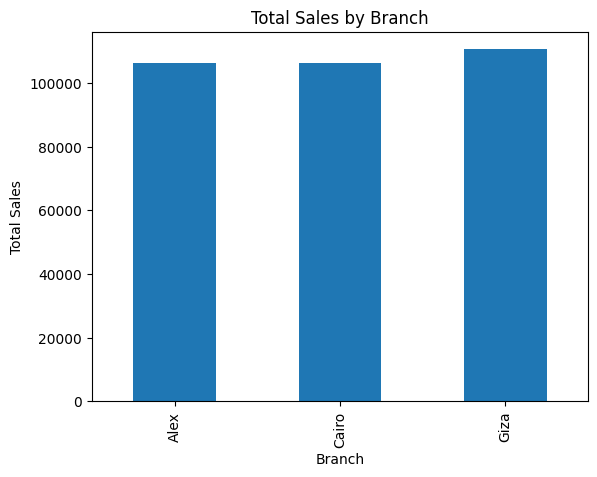

In [ ]:
# highest rates represented visually

branch_sales.plot(kind='bar')
plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
#sales by product line

product_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
product_sales

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


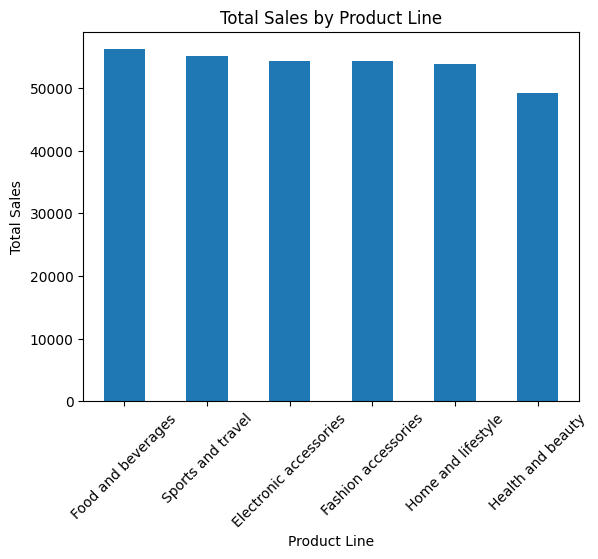

In [ ]:
#sales by product line graph

product_sales.plot(kind='bar')

plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [ ]:
#customer type

customer_sales = df.groupby('Customer type')['Sales'].sum().sort_values(ascending=False)
customer_sales

,Sales
Customer type,
Member,189694.764
Normal,133271.985


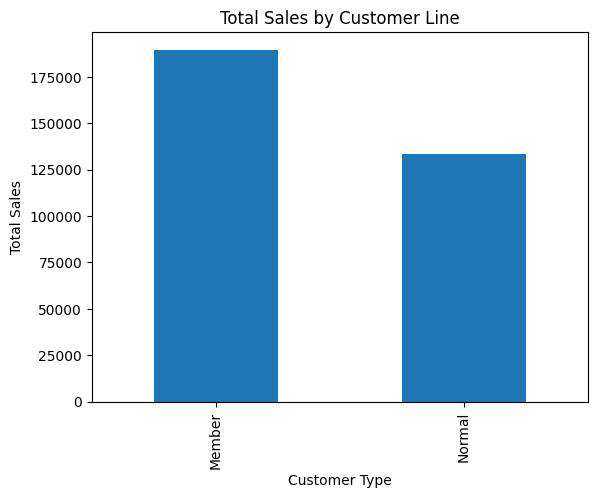

In [ ]:
# customer type visual representation

customer_sales.plot(kind='bar')

plt.title('Total Sales by Customer Line')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')


plt.show()


In [ ]:
#customer average sale

customer_avg_sales = df.groupby('Customer type')['Sales'].mean().sort_values(ascending=False)
customer_avg_sales

,Sales
Customer type,
Member,335.742945
Normal,306.372379


In [ ]:
#customer type total

df['Customer type'].value_counts()

,count
Customer type,
Member,565
Normal,435


In [ ]:
# analysis based on gender

gender_sales = df.groupby('Gender')['Sales'].sum().sort_values(ascending=False)
gender_sales

,Sales
Gender,
Female,194671.8375
Male,128294.9115


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,571
Male,429


In [ ]:
#average sales based on gender

gender_avg_sales = df.groupby('Gender')['Sales'].mean().sort_values(ascending=False)
gender_avg_sales

,Sales
Gender,
Female,340.931414
Male,299.055738


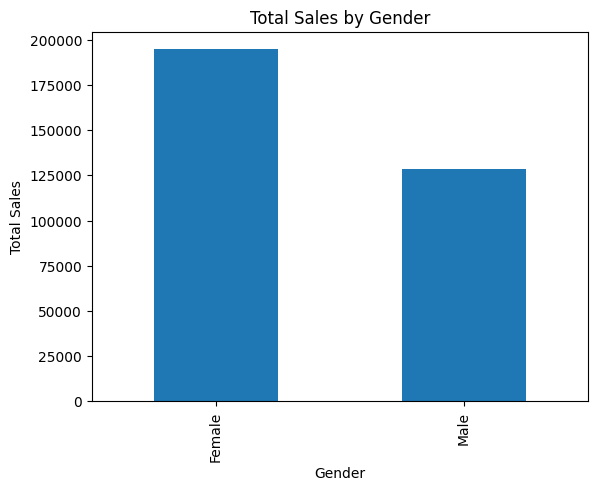

In [ ]:
gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')

plt.show()

Time-based EDA

In [ ]:
#based on week

day_sales = df.groupby('Day_name')['Sales'].sum().sort_values(ascending=False)
day_sales

,Sales
Day_name,
Saturday,56120.8095
Tuesday,51482.2455
Thursday,45349.2480
Sunday,44457.8925
Friday,43926.3405
Wednesday,43731.1350
Monday,37899.0780


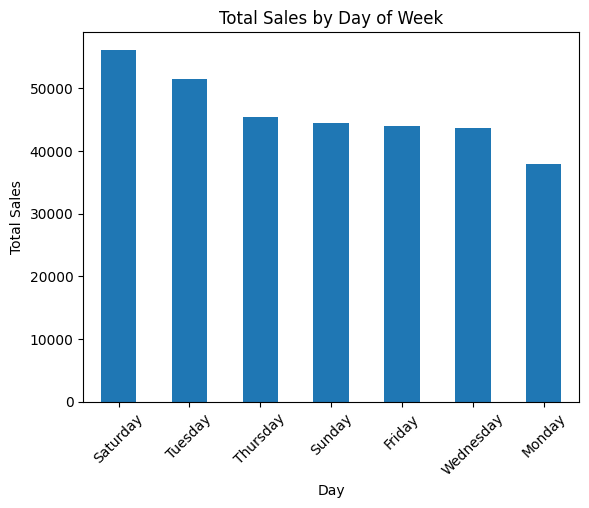

In [ ]:
day_sales.plot(kind='bar')

plt.title('Total Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [ ]:
#based on month

df['Month'] = df['Date'].dt.month_name()

In [ ]:
df['Month_num'] = df['Date'].dt.month

monthly_sales = df.groupby(['Month_num', 'Month'])['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('Month_num')

monthly_sales

,Month_num,Month,Sales
0,1,January,116291.868
1,2,February,97219.374
2,3,March,109455.507


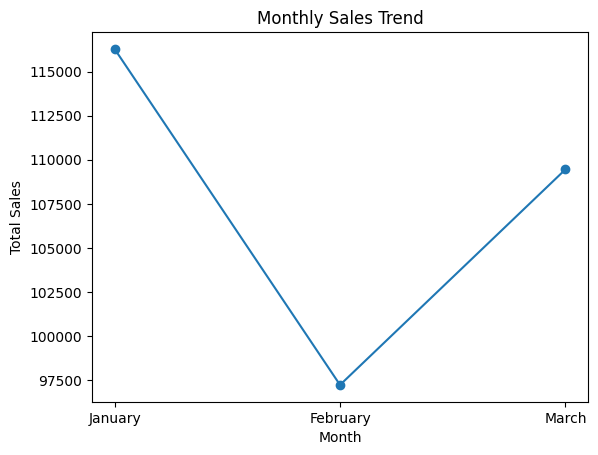

In [ ]:
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

payment method EDA

In [ ]:
payment_counts = df['Payment'].value_counts()
payment_counts

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


In [ ]:
payment_sales = df.groupby('Payment')['Sales'].sum().sort_values(ascending=False)
payment_sales

,Sales
Payment,
Cash,112206.570
Ewallet,109993.107
Credit card,100767.072


In [ ]:
payment_avg_sales = df.groupby('Payment')['Sales'].mean().sort_values(ascending=False)
payment_avg_sales

,Sales
Payment,
Cash,326.181890
Credit card,324.009878
Ewallet,318.820600


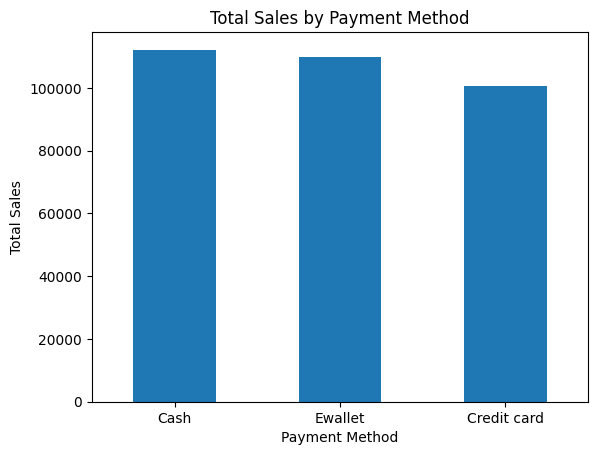

In [ ]:
payment_sales.plot(kind='bar')

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

Correlation Analysis

In [ ]:
df[['Unit price', 'Quantity', 'Sales', 'gross income', 'Rating']].corr()

,Unit price,Quantity,Sales,gross income,Rating
Unit price,1.000000,0.010778,0.633962,0.633962,-0.008778
Quantity,0.010778,1.000000,0.705510,0.705510,-0.015815
Sales,0.633962,0.705510,1.000000,1.000000,-0.036442
gross income,0.633962,0.705510,1.000000,1.000000,-0.036442
Rating,-0.008778,-0.015815,-0.036442,-0.036442,1.000000


In [ ]:
import seaborn as sns

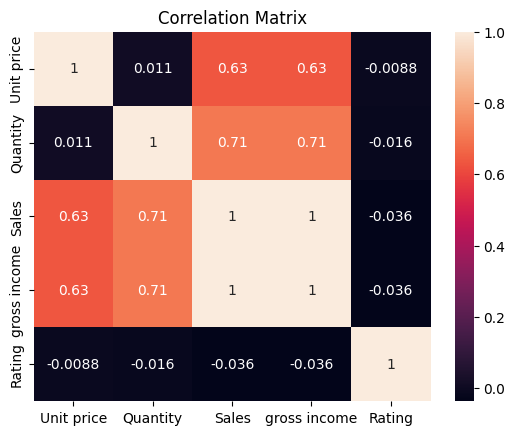

In [ ]:
correlation = df[['Unit price', 'Quantity', 'Sales', 'gross income', 'Rating']].corr()

sns.heatmap(correlation, annot=True)
plt.title('Correlation Matrix')
plt.show()

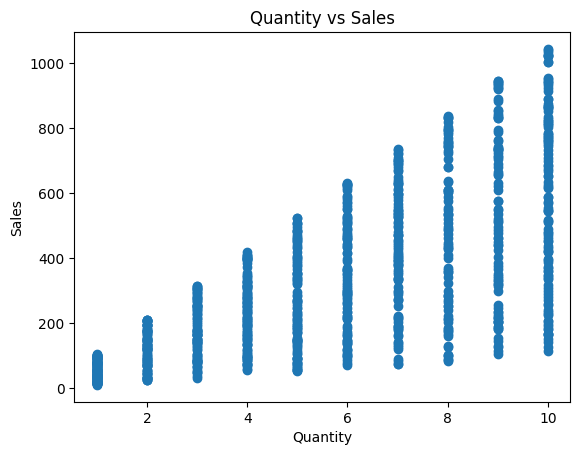

In [ ]:
plt.scatter(df['Quantity'], df['Sales'])
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.title('Quantity vs Sales')
plt.show()

Distribution Analysis

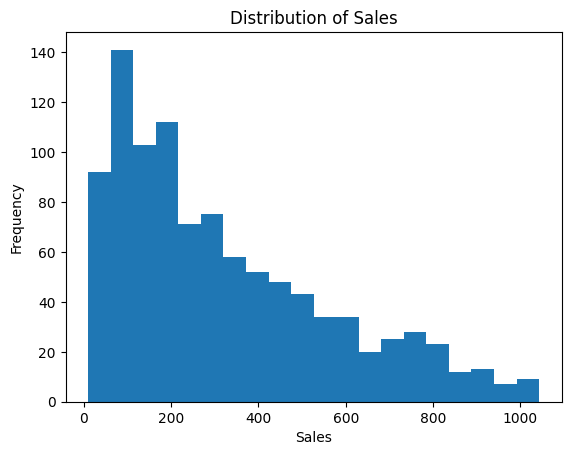

In [ ]:
plt.hist(df['Sales'], bins=20)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

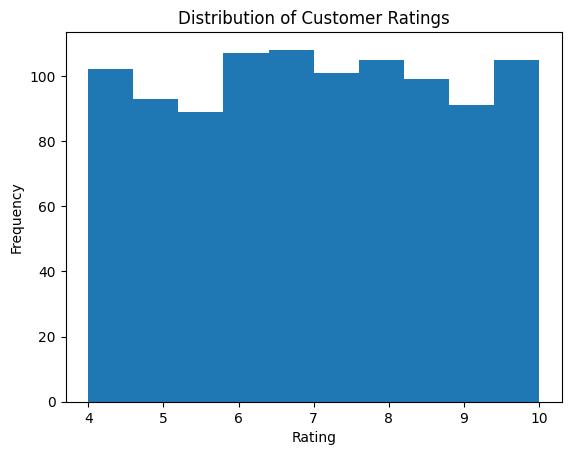

In [ ]:
plt.hist(df['Rating'], bins=10)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

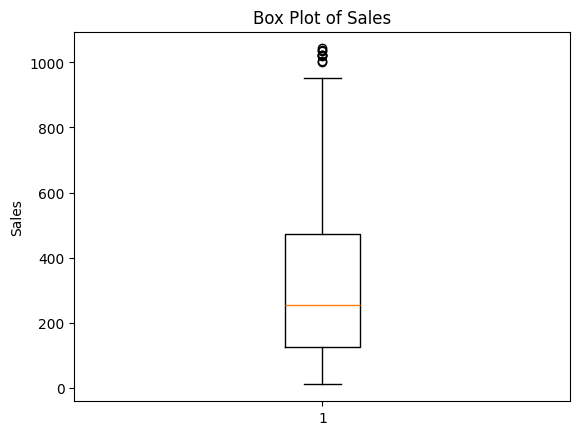

In [ ]:
plt.boxplot(df['Sales'])

plt.title('Box Plot of Sales')
plt.ylabel('Sales')

plt.show()